In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from src.SizeEffects_functions import linear_regression_weighted
from matplotlib.collections import LineCollection
from src.process_data import  process_all_data, create_folder
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/Density/3D/"
#path_sizes = "../results/size_effects/3D/"

create_folder(results_folder)
#create_folder(path_sizes)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep = ' ')
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,128,1,0.00001,1,1.000,1.0,0.1,1,300,0.847211,0.000066,130.896667,0.052347,1.573270e+04,6.592019e+00
1,bond,2,128,2,0.00001,1,1.000,1.0,0.1,1,300,0.848527,0.000065,130.740000,0.051696,1.571977e+04,6.788139e+00
2,bond,2,256,2,0.00001,1,1.000,1.0,0.1,1,73,0.468339,0.000684,352.301370,3.026248,5.406215e+04,7.455232e+01
3,bond,2,128,3,0.00001,1,1.000,1.0,0.1,1,300,0.849420,0.000065,130.830000,0.047961,1.574151e+04,6.340903e+00
4,bond,2,128,5,0.00001,1,1.000,1.0,0.1,1,300,0.852415,0.000067,130.460000,0.054509,1.571086e+04,7.212913e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22770,bond,3,512,65536,0.00010,8,0.125,1.0,0.1,4,12,NaN,NaN,511.000000,0.000000,4.146465e+06,7.274725e+05
22771,bond,3,512,65536,0.00010,8,0.125,1.0,0.1,5,12,NaN,NaN,511.000000,0.000000,5.329066e+06,9.746186e+05
22772,bond,3,512,65536,0.00010,8,0.125,1.0,0.1,6,12,NaN,NaN,511.000000,0.000000,3.891794e+06,9.788174e+05
22773,bond,3,512,65536,0.00010,8,0.125,1.0,0.1,7,12,NaN,NaN,511.000000,0.000000,5.299270e+06,1.294158e+06


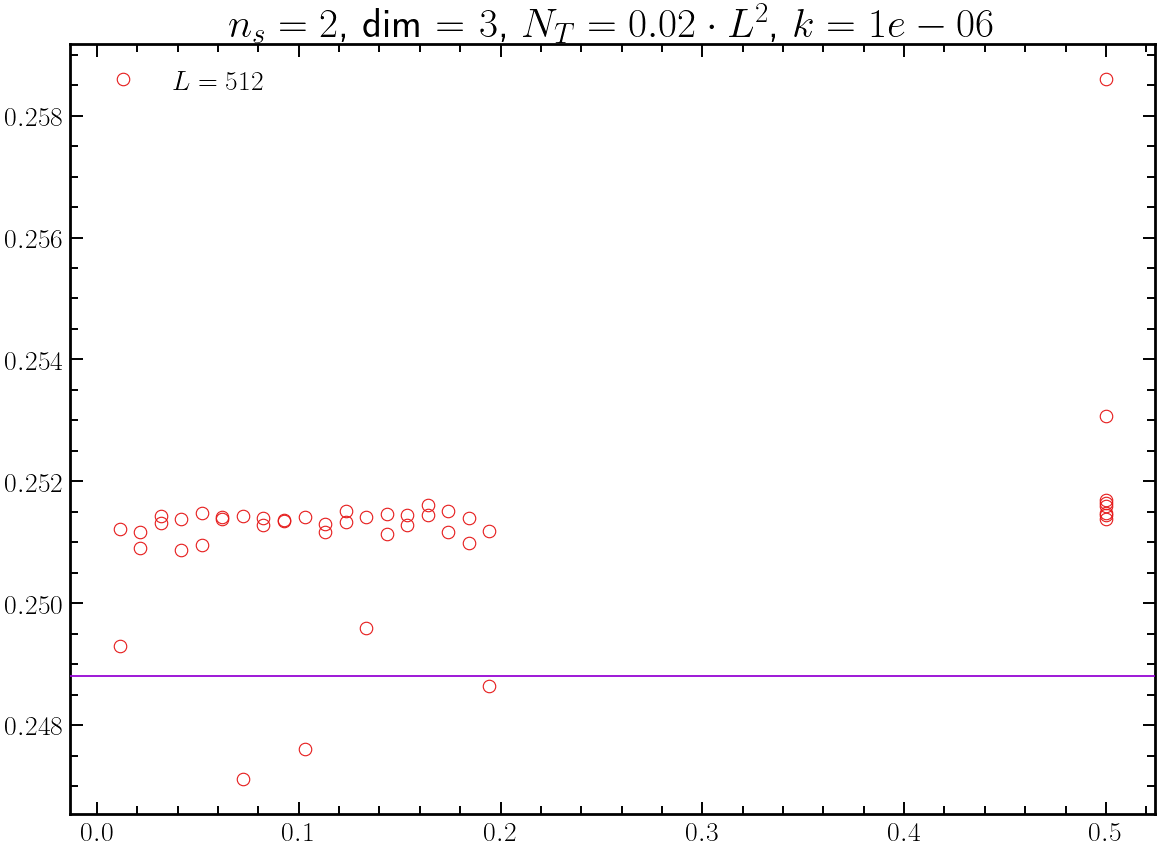

In [19]:
f0 = 0.02
L_lst = [512]
dim = 3
nc = 2
k = 1.0e-06
ord = 1
#df[(df["L"]==L) & (df['dim']==dim) & (df["Nt"]==int(f0*L**2)) & (df['nc']==nc) & (df['k']==k) & (df['order']==ord)]
lw = 2.0
pc = 0.24881182
lw_pc = 1.4
for L in L_lst:
    df_sub = df[(df['nc']==nc) & (df['dim']==dim) & (df['L']==L) & (df["Nt"]==int(f0*L**2))]
    plt.plot(df_sub['rho'], df_sub['p_mean'], 'o' ,label=f"$L = {L}$")

plt.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
# pc_node = 0.31160768
# plt.axhline(y=pc_node, linestyle="-", color="k", lw=lw_pc, alpha=0.9, zorder=5)
plt.legend(fontsize=20)
plt.title(f"$n_s = {nc}$, dim = ${dim}$, $N_T = 0.02 \\cdot L^2$, $k = {k}$", fontsize=30)
#plt.savefig("rho_ns_4.png")
plt.show()